-> Surface adaptability check

In [1]:
import pandas as pd
matches_copy=pd.read_csv("/Users/ssweeti/Desktop/Tennis-project_EDA/tennis_atp-master/matches_cleaned.csv")

Surface Participation Analysis: Unique Players per Court Type


-> This analysis aims to understand how many unique players compete on each tennis court surface.


In [2]:

# Combine winners and losers to capture all players
winners = matches_copy[["surface", "winner_name"]].rename(columns={"winner_name": "player"})
losers = matches_copy[["surface", "loser_name"]].rename(columns={"loser_name": "player"})

all_players = pd.concat([winners, losers])

# Count unique players per surface
surface_player_counts = all_players.groupby("surface")["player"].nunique()

print(surface_player_counts)


surface
Clay     489
Grass    299
Hard     668
Name: player, dtype: int64


Visualization: Player Participation Across Court Surfaces

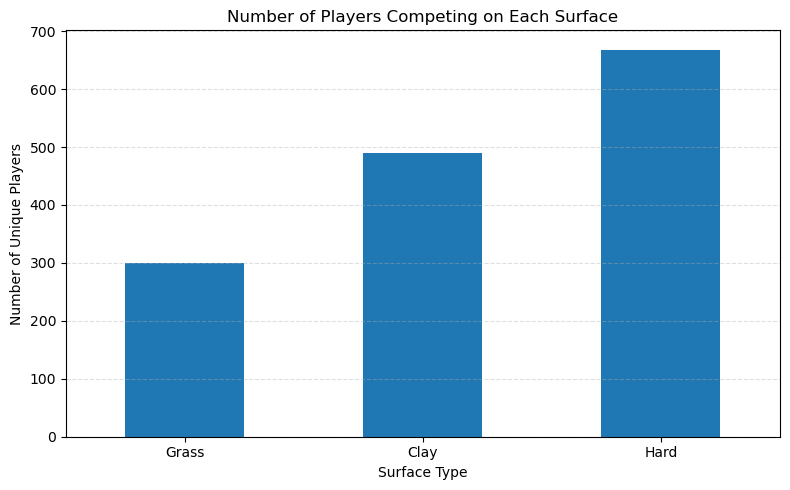

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

surface_player_counts.sort_values().plot(kind="bar")

plt.title("Number of Players Competing on Each Surface")
plt.xlabel("Surface Type")
plt.ylabel("Number of Unique Players")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


Surface Performance Analysis of Top Players

-> This analysis aims to understand how top-performing players perform across different court surfaces.

In [4]:
surface_wins = (
    matches_copy.groupby(["winner_name", "surface"])
      .size()
      .reset_index(name="wins")
)

top_players = (
    matches_copy.groupby("winner_name")
      .size()
      .sort_values(ascending=False)
      .head(5)
      .index
)

surface_wins_top = surface_wins[surface_wins["winner_name"].isin(top_players)]


Visualization: Performance of Top Players Across Court Surfaces

-> This visualization compares how top-performing players perform on different tennis court surfaces.


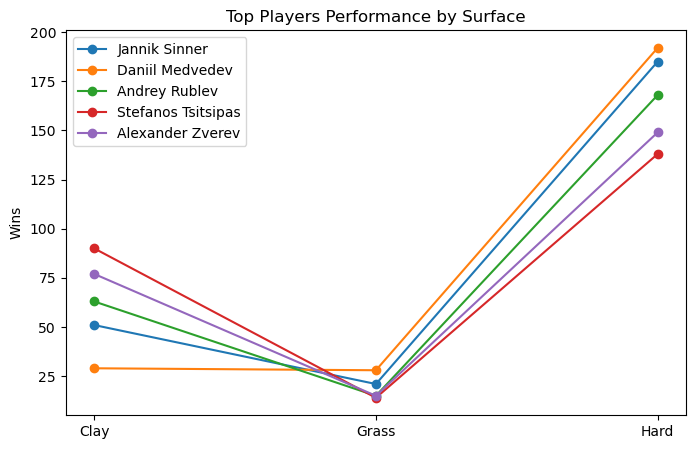

In [5]:
plt.figure(figsize=(8,5))
for player in top_players:
    temp = surface_wins_top[surface_wins_top["winner_name"] == player]
    plt.plot(temp["surface"], temp["wins"], marker="o", label=player)

plt.title("Top Players Performance by Surface")
plt.ylabel("Wins")
plt.legend()
plt.show()
